In [ ]:
!pip install numpy matplotlib japanize-matplotlib


In [2]:
import japanize_matplotlib
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# Transformer の位置符号 Positional Encoding を NumPy で作成するコード
# ============================================================
#
# Transformer は Self-Attention によって系列中の各トークン間の関係を学習する。
# しかし、Self-Attention 自体は入力トークンの「順番」を直接は持たない。
#
# 例えば、以下の2つの文を考える。
#
#   A: 私 は 犬 を 見た
#   B: 犬 は 私 を 見た
#
# 単語の集合だけを見ると、
#   私, は, 犬, を, 見た
# は同じである。
#
# しかし、語順が違うため意味は大きく変わる。
#
# RNN や LSTM では、系列を左から右へ順番に処理するため、
# モデル構造そのものに順序情報が含まれている。
#
# 一方、Transformer の Self-Attention は、
# 各トークンが系列内の他のトークンを一度に参照する構造であり、
# そのままでは「何番目のトークンか」という位置情報を区別しにくい。
#
# そこで、Transformer では単語埋め込み token embedding に
# 位置符号 positional encoding を足し合わせることで、
# 各トークンに「系列中の位置情報」を与える。
#
# 入力表現は概念的に以下のようになる。
#
#   入力ベクトル = 単語埋め込み + 位置符号
#
# 数式で書くと、位置 i の入力ベクトルは以下のように表せる。
#
# Math:
# \mathbf{x}_i = \mathbf{e}_i + \mathbf{p}_i
#
# ここで、
#   \mathbf{e}_i は位置 i の単語埋め込み
#   \mathbf{p}_i は位置 i の位置符号
# を表す。
#
# このコードでは、Transformer の元論文
# "Attention Is All You Need" で使われた
# sin / cos による固定位置符号を作成している。


# K は扱う単語列の最大長を表す。
#
# ここでは最大 50 トークンまでの位置符号を作る。
# つまり、位置 0 から位置 49 までの位置ベクトルを用意する。
#
# 実際のTransformerでは、入力系列長が K 以下であれば、
# その長さに対応する位置符号を取り出して単語埋め込みに加える。
K = 50  # 単語列の最大長


# D は埋め込みベクトルの次元数を表す。
#
# 各トークンは D 次元のベクトルとして表現される。
# そのため、位置符号も単語埋め込みと同じ D 次元でなければならない。
#
# なぜなら、単語埋め込みと位置符号は足し合わせるため、
# 両者の形状が一致している必要があるからである。
#
# Math:
# \mathbf{e}_i \in \mathbb{R}^{D}, \quad \mathbf{p}_i \in \mathbb{R}^{D}
#
# 今回は D = 64 なので、
# 各位置は64次元のベクトルで表される。
D = 64  # 埋め込みの次元


# 位置符号行列 pos_enc を初期化する。
#
# pos_enc の形状は (K, D)。
#
# 行方向:
#   系列中の位置を表す。
#   0行目は位置0、1行目は位置1、...、49行目は位置49に対応する。
#
# 列方向:
#   埋め込みベクトルの各次元を表す。
#   0列目から63列目まで、合計64次元の位置情報を持つ。
#
# つまり、pos_enc[i] は位置 i に対応する D 次元の位置ベクトルである。
#
# np.empty は配列領域だけを確保し、中身を初期化しない。
# この後の for ループですべての要素に値を代入するため、
# ここでは np.zeros ではなく np.empty を使っても問題ない。
pos_enc = np.empty((K, D))


# ============================================================
# sin / cos による位置符号の計算
# ============================================================
#
# Transformer の固定位置符号では、偶数次元に sin、奇数次元に cos を使う。
#
# 元論文の式は以下である。
#
# Math:
# PE(pos, 2i) = \sin\left(\frac{pos}{10000^{2i / d_{\mathrm{model}}}}\right)
#
# Math:
# PE(pos, 2i + 1) = \cos\left(\frac{pos}{10000^{2i / d_{\mathrm{model}}}}\right)
#
# このコードでは、
#   pos を i
#   次元ペアのインデックスを k
#   d_model を D
# として実装している。
#
# 注意:
#   コード中の i は「位置」を表している。
#   数式中でよく使われる i は「次元ペア」を表すことがある。
#   混乱しやすいので、ここでは k を次元ペアの番号として使っている。


# 単語位置 i でループする。
#
# i = 0 のときは文頭の位置、
# i = 1 のときは2番目のトークンの位置、
# ...
# i = 49 のときは50番目のトークンの位置に対応する。
#
# 各位置 i に対して、64次元の位置符号ベクトル pos_enc[i] を作る。
for i in range(K):
    # k は sin / cos のペア番号を表す。
    #
    # D = 64 の場合、偶数次元と奇数次元をペアにして扱うため、
    # ペア数は D // 2 = 32 になる。
    #
    # k = 0 のとき:
    #   0次元目に sin
    #   1次元目に cos
    #
    # k = 1 のとき:
    #   2次元目に sin
    #   3次元目に cos
    #
    # k = 2 のとき:
    #   4次元目に sin
    #   5次元目に cos
    #
    # という形で、2次元ずつ埋めていく。
    for k in range(D // 2):
        # theta は、位置 i と次元 k に応じた角度を表す。
        #
        # Math:
        # \theta = \frac{i}{10000^{2k / D}}
        #
        # 位置 i が大きくなるほど theta は大きくなる。
        # 一方、k が大きくなるほど分母が大きくなるため、
        # theta の変化はゆっくりになる。
        #
        # つまり、低い次元では短い周期の sin / cos、
        # 高い次元では長い周期の sin / cos が使われる。
        #
        # これにより、位置符号は複数の周波数成分を持つ。
        #
        # 直感的には、
        #   低次元: 近い位置の違いを細かく表す
        #   高次元: 遠い位置関係をゆっくり表す
        # という役割を持つ。
        theta = i / (10000 ** (2 * k / D))

        # 偶数次元 2k には sin(theta) を代入する。
        #
        # sin を使うことで、位置 i に応じて周期的に値が変化する。
        #
        # 例:
        #   k = 0 のときは pos_enc[i, 0]
        #   k = 1 のときは pos_enc[i, 2]
        #   k = 2 のときは pos_enc[i, 4]
        #
        # のように、偶数番目の次元に入る。
        pos_enc[i, 2 * k] = np.sin(theta)

        # 奇数次元 2k + 1 には cos(theta) を代入する。
        #
        # sin と cos は位相がずれた関数である。
        # 同じ theta に対して sin と cos の両方を使うことで、
        # 位置の情報を2次元の組として表現できる。
        #
        # sin / cos のペアには重要な性質がある。
        # 位置を一定量ずらしたとき、その変化を線形変換として表しやすい。
        #
        # そのため、Transformer が相対的な位置関係を学習しやすくなると考えられている。
        pos_enc[i, 2 * k + 1] = np.cos(theta)


# ここまでで、pos_enc には以下のような行列が入っている。
#
# Math:
# \mathrm{pos\_enc} \in \mathbb{R}^{K \times D}
#
# 今回の設定では、形状は以下になる。
#
# Math:
# \mathrm{pos\_enc} \in \mathbb{R}^{50 \times 64}
#
# 各行 pos_enc[i] が、位置 i の64次元ベクトルである。
#
# この位置符号を Transformer の入力に使う場合は、
# 単語埋め込み token_emb と同じ形にして足し合わせる。
#
# 例:
#   token_emb の形状: (系列長, D)
#   pos_enc[:系列長] の形状: (系列長, D)
#
# Math:
# \mathrm{input} = \mathrm{token\_emb} + \mathrm{pos\_enc}
#
# これにより、モデルは
#   「どの単語か」
# だけでなく、
#   「何番目に出てきた単語か」
# も同時に扱えるようになる。


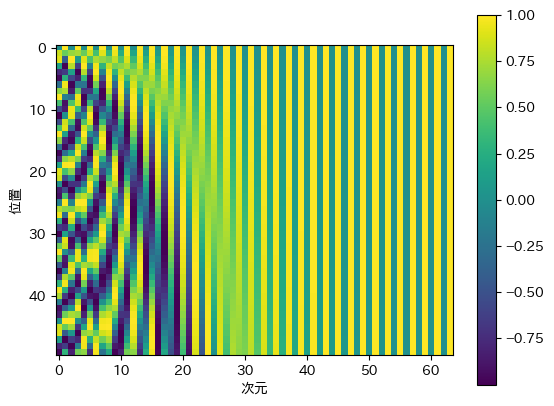

In [3]:
# ============================================================
# 位置符号行列 pos_enc をヒートマップとして可視化するコード
# ============================================================
#
# 前のコードで作成した pos_enc は、形状が (K, D) の2次元配列である。
#
# Math:
# \mathrm{pos\_enc} \in \mathbb{R}^{K \times D}
#
# 今回の設定では、K = 50, D = 64 なので、
#
# Math:
# \mathrm{pos\_enc} \in \mathbb{R}^{50 \times 64}
#
# となる。
#
# 行方向は「位置」、列方向は「埋め込み次元」を表す。
#
#   pos_enc[i, j]
#
# は、
#
#   位置 i における j 次元目の位置符号の値
#
# を意味する。
#
# この行列を画像として表示することで、
# sin / cos による位置符号がどのようなパターンを持っているかを確認できる。


# plt.imshow は、2次元配列を画像として表示する関数。
#
# pos_enc の各要素の値を色に変換して表示する。
#
# 位置符号は sin / cos で作られているため、
# 各値は基本的に -1 から 1 の範囲に収まる。
#
# 値が大きい部分と小さい部分が色の違いとして表れるため、
# 次元ごと・位置ごとの周期的な変化を視覚的に確認できる。
#
# ヒートマップとして見ると、
# 低い次元では位置に対して値が速く変化し、
# 高い次元ではゆっくり変化する傾向が見える。
#
# これは、位置符号が複数の周波数を組み合わせて作られているためである。
im = plt.imshow(pos_enc)

# X軸のラベルを設定する。
#
# X軸は pos_enc の列方向に対応する。
# つまり、埋め込みベクトルの次元を表す。
#
# 例えば D = 64 の場合、
# X軸には 0 から 63 までの次元が並ぶ。
#
# 偶数次元には sin が入り、
# 奇数次元には cos が入っている。
#
# Math:
# PE(pos, 2k) = \sin\left(\frac{pos}{10000^{2k / D}}\right)
#
# Math:
# PE(pos, 2k + 1) = \cos\left(\frac{pos}{10000^{2k / D}}\right)
#
# そのため、隣り合う2次元が1つの周波数ペアとして機能する。
plt.xlabel("次元")  # X軸のラベルを設定

# Y軸のラベルを設定する。
#
# Y軸は pos_enc の行方向に対応する。
# つまり、入力系列中の位置を表す。
#
# 例えば K = 50 の場合、
# Y軸には 0 から 49 までの位置が並ぶ。
#
# 位置0は文頭のトークン、
# 位置1は2番目のトークン、
# 位置2は3番目のトークン、
# というように対応する。
#
# Transformerでは、この位置ごとのベクトルを単語埋め込みに足すことで、
# モデルに語順情報を与える。
plt.ylabel("位置")  # Y軸のラベルを設定

# plt.colorbar は、画像中の色と数値の対応関係を示すバーを追加する。
#
# pos_enc の値は sin / cos によって計算されているため、
# 理論上は -1 から 1 の範囲を取る。
#
# colorbar を付けることで、
# どの色が正の値・負の値・0付近を表しているかを確認できる。
#
# これにより、位置符号の周期的な増減や、
# 次元ごとの変化の速さを読み取りやすくなる。
plt.colorbar(im)  # 値と色の対応を示すバーを付加

# 作成した図を表示する。
#
# Jupyter Notebook や Google Colab では、この行を実行すると
# セルの出力としてヒートマップが表示される。
#
# この可視化から確認したいポイントは以下である。
#
# 1. 行方向、つまり位置方向に沿って値が周期的に変化していること
# 2. 次元によって周期の長さが異なること
# 3. 偶数次元と奇数次元が sin / cos のペアとしてずれて変化していること
# 4. Transformer が単語埋め込みに加える位置情報が、単なる整数番号ではなく、
#    多次元の連続ベクトルとして表現されていること
#
# 特に、低次元側では縞模様が細かくなりやすく、
# 高次元側ではゆっくりした変化になりやすい。
# これは、低次元ほど高周波、高次元ほど低周波の位置情報を持つためである。
plt.show()


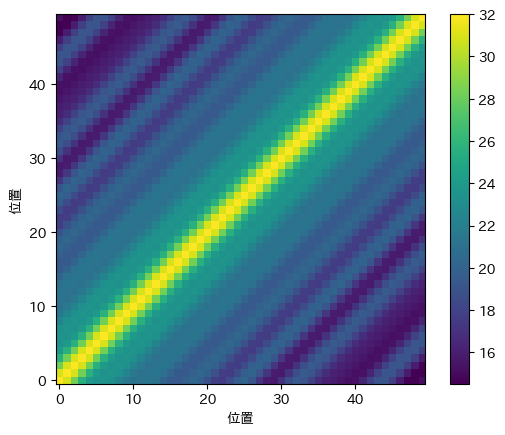

In [4]:
# ============================================================
# 位置符号ベクトル同士の内積を計算し、位置間の類似度を可視化するコード
# ============================================================
#
# 前のコードで作成した pos_enc は、Transformer の位置符号行列である。
#
# pos_enc の形状は以下である。
#
# Math:
# \mathrm{pos\_enc} \in \mathbb{R}^{K \times D}
#
# 今回の例では、K = 50, D = 64 なので、
#
# Math:
# \mathrm{pos\_enc} \in \mathbb{R}^{50 \times 64}
#
# となる。
#
# 各行 pos_enc[i] は、位置 i に対応する D 次元の位置ベクトルである。
#
# つまり、
#
#   pos_enc[0] → 位置0の位置ベクトル
#   pos_enc[1] → 位置1の位置ベクトル
#   pos_enc[2] → 位置2の位置ベクトル
#
# のように、各位置が1本のベクトルとして表現されている。
#
# このコードでは、それぞれの位置ベクトル同士がどれくらい似ているかを
# 内積によって計算している。


# 位置符号同士の内積を計算する。
#
# pos_enc の形状:
#
# Math:
# \mathrm{pos\_enc} \in \mathbb{R}^{K \times D}
#
# pos_enc.T の形状:
#
# Math:
# \mathrm{pos\_enc}^{T} \in \mathbb{R}^{D \times K}
#
# したがって、行列積 np.matmul(pos_enc, pos_enc.T) の結果は、
#
# Math:
# \mathrm{dot\_matrix}
# =
# \mathrm{pos\_enc}
# \mathrm{pos\_enc}^{T}
# \in \mathbb{R}^{K \times K}
#
# になる。
#
# dot_matrix[i, j] は、位置 i の位置符号ベクトルと
# 位置 j の位置符号ベクトルの内積を表す。
#
# Math:
# \mathrm{dot\_matrix}[i, j]
# =
# \mathbf{p}_i^{T}\mathbf{p}_j
#
# ここで、
#   \mathbf{p}_i は位置 i の位置符号ベクトル
#   \mathbf{p}_j は位置 j の位置符号ベクトル
# を表す。
#
# 内積が大きい:
#   2つの位置符号ベクトルの向きが近い
#
# 内積が小さい:
#   2つの位置符号ベクトルの向きがあまり近くない
#
# 位置符号は sin / cos の組で作られているため、
# 位置 i と位置 j の内積は、絶対位置そのものだけでなく、
# 位置差 |i - j| に強く依存する構造を持つ。
#
# これは Transformer が「位置同士の相対的な近さ」を扱う上で重要な性質である。
dot_matrix = np.matmul(pos_enc, pos_enc.T)


# ============================================================
# 内積行列 dot_matrix をヒートマップとして表示する
# ============================================================
#
# dot_matrix の形状は (K, K) である。
#
# 今回は K = 50 なので、
#
# Math:
# \mathrm{dot\_matrix} \in \mathbb{R}^{50 \times 50}
#
# となる。
#
# 行方向も列方向も「位置」を表す。
#
# つまり、ヒートマップ上の座標 (i, j) の色は、
# 位置 i と位置 j の位置符号ベクトルの内積を表している。


# plt.imshow は、2次元行列を画像として表示する関数。
#
# dot_matrix の各要素を色に変換して表示する。
#
# origin="lower" は、画像の原点を左下にする指定。
#
# 通常、imshow は配列の0行目を画像の上側に表示する。
# しかし、origin="lower" を指定すると、
# 0行目が下側に表示される。
#
# これにより、数学の座標軸に近い感覚で、
# 横軸と縦軸の位置番号を読むことができる。
im = plt.imshow(dot_matrix, origin="lower")


# X軸のラベルを設定する。
#
# X軸は dot_matrix の列インデックス j に対応する。
#
# つまり、比較対象となる位置 j を表している。
#
# 例えば、横軸が 10 の位置にある列を見ると、
# すべての位置 i と位置10の位置符号の内積を確認できる。
plt.xlabel("位置")


# Y軸のラベルを設定する。
#
# Y軸は dot_matrix の行インデックス i に対応する。
#
# つまり、基準となる位置 i を表している。
#
# dot_matrix[i, j] と dot_matrix[j, i] は同じ値になる。
# なぜなら、内積は交換可能だからである。
#
# Math:
# \mathbf{p}_i^{T}\mathbf{p}_j
# =
# \mathbf{p}_j^{T}\mathbf{p}_i
#
# そのため、このヒートマップは対角線に対して対称な模様になる。
plt.ylabel("位置")


# colorbar を追加する。
#
# colorbar は、ヒートマップの色がどの数値に対応しているかを示す。
#
# dot_matrix の値が大きいほど、
# 2つの位置符号ベクトルの内積が大きいことを意味する。
#
# 特に、対角成分 dot_matrix[i, i] は、
# 位置 i のベクトルと自分自身の内積である。
#
# Math:
# \mathrm{dot\_matrix}[i, i]
# =
# \mathbf{p}_i^{T}\mathbf{p}_i
# =
# \|\mathbf{p}_i\|^2
#
# これはベクトルの長さの2乗なので、基本的に大きな値になる。
#
# そのため、ヒートマップでは対角線付近が強く表示されやすい。
plt.colorbar(im)


# 図を表示する。
#
# この可視化で確認したいポイントは以下である。
#
# 1. 対角線上の値が大きいこと
#    同じ位置同士の内積なので、最も似ている。
#
# 2. 対角線から離れるにつれて値が変化すること
#    位置が離れるほど、位置符号ベクトルの類似度が変わる。
#
# 3. 行列が対称になること
#    位置 i と位置 j の内積は、位置 j と位置 i の内積と同じ。
#
# 4. 斜め方向に規則的な模様が出ること
#    sin / cos による位置符号では、位置差に応じた周期的な構造が現れる。
#
# この図を見ることで、Transformer の固定位置符号が、
# 各位置を完全に独立したIDとしてではなく、
# 「近い位置はある程度似ていて、離れた位置は異なる」
# ような連続的なベクトル空間として表現していることが分かる。
plt.show()
